# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [27]:
#! pip install mne

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

from scripts import global_settings, trial_dynamics, sliding_window, erp_window

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

In [29]:
# CONDITION   = "BLT"
# ONSET_MS = 500

CONDITION   = "BLT"
ONSET_MS = 500

SUBJECT_IDS = np.setdiff1d(np.arange(1,18,1), [1, 4, 14])
CHANNELS    = "all"                 # T7, T8, TP7, TP8
FREQ_BANDS  = "delta_beta"          # 0.5–30Hz
NORM_DICT = {
    "BASELINE": "center", # "center", "zscore", None
    "GLOBAL": "zscore",   # "zscore", "max", None
}

all_sub_data = {}
all_data_bc_list = []
all_trial_rows = []

BASELINE_TMIN = -0.500
BASELINE_TMAX = -0.050

for sub_id in SUBJECT_IDS:
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    n_trials, n_channels, n_times = data.shape

    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    baseline_std  = data[:, :, baseline_mask].std(axis=-1, keepdims=True)

    baseline_std[baseline_std == 0] = np.nan

    if NORM_DICT["BASELINE"] == "center":
        data_bc = data - baseline_mean
    elif NORM_DICT["BASELINE"] == "zscore":
        data_bc = (data - baseline_mean) / baseline_std   # z-score baseline corrected
    else:
        data_bc = data

    if NORM_DICT["GLOBAL"] == "zscore":
        global_mean = np.nanmean(data_bc)
        global_std = np.nanstd(data_bc)
        data_bc = (data_bc - global_mean) / global_std
    elif NORM_DICT["GLOBAL"] == "max":
        global_max = np.nanmax(np.abs(data_bc))
        data_bc = data_bc / global_max

    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_times": n_times,
    }

    all_data_bc_list.append(data_bc)

    for t in range(n_trials):
        all_trial_rows.append({
            "sub_id": sub_id,
            "trial_index": t + 1,
        })

    print(
        f"Loaded Subject {sub_id} | trials={n_trials}, "
        f"channels={n_channels}, times={n_times}"
    )

ref_sub = SUBJECT_IDS[0]
times = all_sub_data[ref_sub]["times"]
ch_names = all_sub_data[ref_sub]["ch_names"]
time_ms = times * 1000

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 2 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 3 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Loaded Subject 15 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 16 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 17 | trials=60, channels=32, times=1792


In [30]:
# -------------------------
# 3.1) select channels for ROI grand average
# -------------------------
ROI_NAME = "all_rois"
SELECTED_CHANNELS = global_settings.roi_dict[ROI_NAME]

# -------------------------
# 3) concatenate all subjects after each was corrected separately
# -------------------------
all_data_bc = np.concatenate(all_data_bc_list, axis=0)   # (total_trials, n_channels, n_times)

print("All-subject concatenated data_bc shape:", all_data_bc.shape)



selected_idx = [ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in ch_names]
selected_ch_names = [ch_names[i] for i in selected_idx]

all_data_bc_sel = all_data_bc[:, selected_idx, :]   # (total_trials, n_selected_channels, n_times)

print("Selected channels:", selected_ch_names)
print("all_data_bc_sel shape:", all_data_bc_sel.shape)

# channel-wise grand average on selected channels only
grand_avg_by_channel = np.nanmean(all_data_bc_sel, axis=0)   # (n_selected_channels, T)

# ROI average across selected channels
grand_avg = np.nanmean(grand_avg_by_channel, axis=0)   # (T,)

print("grand_avg_by_channel shape:", grand_avg_by_channel.shape)
print("grand_avg shape:", grand_avg.shape)

All-subject concatenated data_bc shape: (840, 32, 1792)
Selected channels: ['F3', 'FZ', 'F4', 'FC1', 'FC2', 'Cz', 'C3', 'C4', 'CP3', 'CPZ', 'CP4', 'CP1', 'CP2', 'P1', 'P2', 'POz']
all_data_bc_sel shape: (840, 16, 1792)
grand_avg_by_channel shape: (16, 1792)
grand_avg shape: (1792,)


In [31]:
print(ch_names)

['AF7', 'FPZ', 'AF8', 'AF3', 'AF4', 'F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'POz', 'O1', 'Oz', 'O2']


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50             525    525.390625 -0.030087            520.0          570.0   
N100            540    554.687500 -0.037548            550.0          620.0   
P200            609    689.453125  0.023536            600.0          700.0   
N200            637    744.140625 -0.045036            630.0          760.0   
P300            699    865.234375  0.055215            720.0          920.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50            pos      510.390625    540.390625                 15.0  
N100           neg      529.687500    579.687500                 25.0  
P200           pos      664.453125    714.453125                 25.0  
N200           neg      719.140625    769.140625                 25.0  
P300          

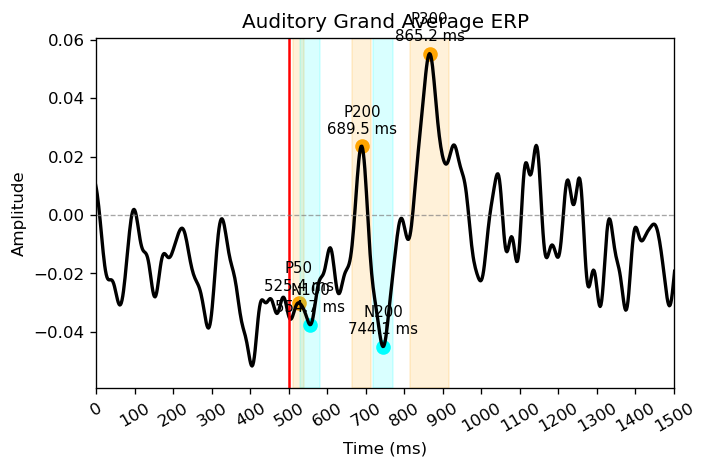

In [32]:
res_aud = erp_window.detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg,
    search_windows=global_settings.SEARCH_DICT[CONDITION]["search_windows"],
    onset_ms = ONSET_MS,
    polarity_map=global_settings.SEARCH_DICT[CONDITION]["polarity_map"],
    half_width_map=global_settings.half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print(res_aud)
erp_window.plot_grand_avg_with_windows(
    time_ms=time_ms,
    grand_avg=grand_avg,
    res_df=res_aud,
    title="Auditory Grand Average ERP",
    onset_ms=ONSET_MS,
    figsize=(6,4)
)

## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [33]:
import numpy as np
import pandas as pd

# =========================
# 1) read time_wind
# =========================

component_windows = {
    comp: {
        "tmin_s": row["final_start_ms"] / 1000.0,
        "tmax_s": row["final_end_ms"] / 1000.0,
        "polarity": row["polarity"],
    }
    for comp, row in res_aud.iterrows()
}

print("Detected windows from res_aud:")
for comp, info in component_windows.items():
    print(
        f"  {comp}: {info['tmin_s']*1000:.1f}–{info['tmax_s']*1000:.1f} ms "
        f"(polarity={info['polarity']})"
    )

all_features_df_list = []
all_roi_features_df_list = [] 

for sub_id in SUBJECT_IDS:
    sub_pack = all_sub_data[sub_id]
    data_bc = sub_pack["data_bc"]          # (n_trials, n_channels, n_times)
    times   = sub_pack["times"]
    ch_names = SELECTED_CHANNELS

    n_trials, n_channels, _ = data_bc.shape

    # =========================
    # 1) build window masks
    # =========================
    window_masks = {}
    for comp, info in component_windows.items():
        mask = (times >= info["tmin_s"]) & (times <= info["tmax_s"])
        window_masks[comp] = mask

    # =========================
    # 2) extract mean amp
    # =========================
    feat_mean = {}
    for comp, mask in window_masks.items():
        # (n_trials, n_channels)
        feat_mean[comp] = np.nanmean(data_bc[:, :, mask], axis=-1)

    # =========================
    # 3) extract peak amp / latency
    # =========================
    feat_peak_amp = {}
    feat_peak_lat_ms = {}

    for comp, mask in window_masks.items():
        polarity = component_windows[comp]["polarity"]
        times_win = times[mask]
        win_data = data_bc[:, :, mask]   # (n_trials, n_channels, samples)

        if polarity == "pos":
            peak_ix = np.nanargmax(win_data, axis=-1)
        elif polarity == "neg":
            peak_ix = np.nanargmin(win_data, axis=-1)
        else:
            raise ValueError(f"Unknown polarity for {comp}: {polarity}")

        peak_amp = np.take_along_axis(
            win_data,
            peak_ix[..., None],
            axis=-1
        ).squeeze(-1)

        peak_lat_ms = times_win[peak_ix] * 1000.0

        feat_peak_amp[comp] = peak_amp
        feat_peak_lat_ms[comp] = peak_lat_ms

    # =========================
    # 4) trial × channel features_df
    # =========================
    rows = []
    for t in range(n_trials):
        for c, ch in enumerate(ch_names):
            row = {
                "sub_id": sub_id,
                "trial_index": t + 1,
                "channel": ch,
            }

            for comp in component_windows.keys():
                row[f"{comp}_mean_amp"] = feat_mean[comp][t, c]
                row[f"{comp}_peak_amp"] = feat_peak_amp[comp][t, c]
                row[f"{comp}_peak_lat_ms"] = feat_peak_lat_ms[comp][t, c]

            rows.append(row)

    features_df_sub = pd.DataFrame(rows)
    all_features_df_list.append(features_df_sub)

    # =========================
    # 5) ROI average across channels
    # =========================
    roi_rows = []
    for t in range(n_trials):
        row = {
            "sub_id": sub_id,
            "trial_index": t + 1,
        }

        for comp in component_windows.keys():
            row[f"{comp}_mean_amp_roi"] = np.nanmean(feat_mean[comp][t])
            row[f"{comp}_peak_amp_roi"] = np.nanmean(feat_peak_amp[comp][t])
            row[f"{comp}_peak_lat_ms_roi"] = np.nanmean(feat_peak_lat_ms[comp][t])

        roi_rows.append(row)

    roi_features_df_sub = pd.DataFrame(roi_rows)
    all_roi_features_df_list.append(roi_features_df_sub)

erp_features_all_df = pd.concat(all_features_df_list, ignore_index=True)
erp_roi_features_all_df = pd.concat(all_roi_features_df_list, ignore_index=True)

print("Per-channel feature df:")
display(erp_features_all_df.head())

print("ROI feature df:")
display(erp_roi_features_all_df.head())

Detected windows from res_aud:
  P50: 510.4–540.4 ms (polarity=pos)
  N100: 529.7–579.7 ms (polarity=neg)
  P200: 664.5–714.5 ms (polarity=pos)
  N200: 719.1–769.1 ms (polarity=neg)
  P300: 815.2–915.2 ms (polarity=pos)
Per-channel feature df:


,sub_id,trial_index,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,P200_peak_lat_ms,N200_mean_amp,N200_peak_amp,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms
0,2,1,F3,0.081266,0.531965,539.06250,0.730079,0.161547,531.250,-0.539612,-0.236554,673.828125,-0.258664,-1.255784,767.578125,-0.337307,0.336960,886.718750
1,2,1,FZ,-0.005586,0.447075,511.71875,-0.006390,-0.648246,578.125,-0.480157,0.025326,666.015625,-0.369791,-1.842819,767.578125,0.054767,0.877835,837.890625
2,2,1,F4,0.330697,0.633921,539.06250,1.130530,0.313870,531.250,-1.096613,-0.093711,666.015625,-0.734754,-1.722706,767.578125,-0.355767,0.967706,886.718750
3,2,1,FC1,-0.100817,0.250564,539.06250,0.152556,-0.144207,531.250,-0.353943,-0.076453,707.031250,-0.943444,-2.087343,767.578125,0.277570,1.491262,841.796875
4,2,1,FC2,0.105793,0.397710,539.06250,0.404384,0.044306,578.125,-0.682569,-0.411079,710.937500,-0.814394,-1.816681,767.578125,-0.025486,0.844201,839.843750


ROI feature df:


,sub_id,trial_index,P50_mean_amp_roi,P50_peak_amp_roi,P50_peak_lat_ms_roi,N100_mean_amp_roi,N100_peak_amp_roi,N100_peak_lat_ms_roi,P200_mean_amp_roi,P200_peak_amp_roi,P200_peak_lat_ms_roi,N200_mean_amp_roi,N200_peak_amp_roi,N200_peak_lat_ms_roi,P300_mean_amp_roi,P300_peak_amp_roi,P300_peak_lat_ms_roi
0,2,1,2.909989e-10,0.249566,528.320312,4.695863e-09,-0.467008,556.884766,6.032233e-11,0.445714,691.406250,-2.772934e-09,-0.688358,741.577148,6.133688e-10,0.886069,865.051270
1,2,2,1.186093e-08,0.497731,527.465820,6.677425e-09,-0.427490,558.593750,1.065334e-09,0.734487,691.528320,-3.622213e-09,-0.706799,739.868164,-5.409964e-11,1.151995,861.389160
2,2,3,-3.818483e-10,0.854328,525.268555,1.322926e-08,-0.632750,552.978516,6.005252e-09,0.606375,687.500000,1.805745e-08,-0.808670,739.074707,5.468714e-09,0.918787,865.539551
3,2,4,-8.552158e-09,0.881558,521.789551,-3.688973e-09,-0.682664,555.236816,2.769607e-09,0.854720,687.866211,1.483066e-08,-0.414594,745.483398,1.572944e-09,0.759695,859.924316
4,2,5,2.998461e-09,0.553670,524.963379,6.709125e-09,-0.608880,556.457520,4.509895e-10,0.708131,691.101074,3.721854e-09,-0.785954,741.882324,8.299713e-09,1.117535,877.563477


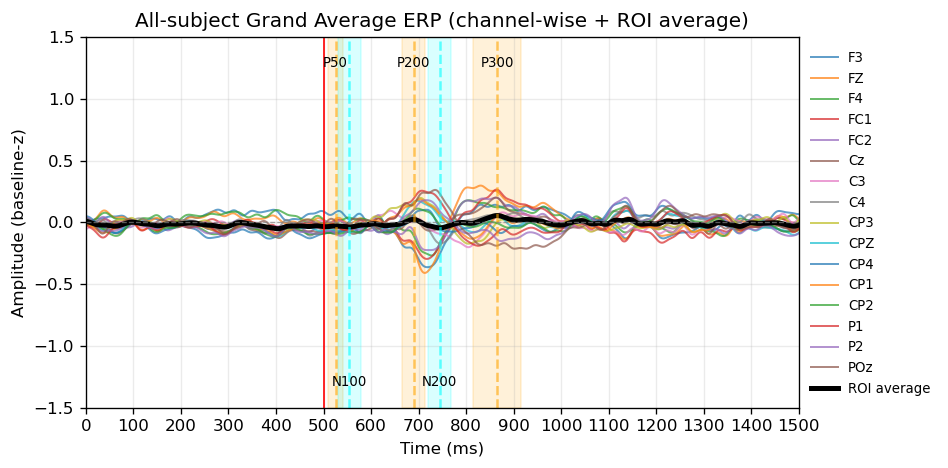

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
observe_range = 1.5
for c, ch in enumerate(ch_names):
    ax.plot(
        time_ms,
        grand_avg_by_channel[c],
        linewidth=1.2,
        alpha=0.7,
        label=ch
    )

ax.plot(
    time_ms,
    grand_avg,
    color="black",
    linewidth=3,
    label="ROI average"
)

min_amp = np.nanmin(grand_avg)
max_amp = np.nanmax(grand_avg)

for comp, row in res_aud.iterrows():
    color = "orange" if row["polarity"] == "pos" else "cyan"
    text_pos_y = -observe_range * 0.9 if row["polarity"] == "neg" else observe_range * 0.9
    ax.axvspan(
        row["final_start_ms"],
        row["final_end_ms"],
        alpha=0.15,
        color=color
    )
    ax.axvline(row["peak_time_ms"], linestyle="--", alpha=0.6, color=color)
    
    ax.text(
        row["peak_time_ms"],
        text_pos_y,
        comp,
        fontsize=8,
        ha="center",
        va="bottom" if row["polarity"] == "neg" else "top",
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(ONSET_MS, color="red", linestyle="-", linewidth=1, alpha=1.0)

ax.set_title("All-subject Grand Average ERP (channel-wise + ROI average)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (baseline-z)")
ax.set_xlim(-500+ONSET_MS, 800+ONSET_MS)
ax.set_xticks(np.arange(-500+ONSET_MS, 1001+ONSET_MS, 100))
ax.set_ylim(-observe_range, observe_range)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0), fontsize=8,frameon=False)

plt.tight_layout()
plt.show()

## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

In [47]:
erp_roi_features_df, erp_roi_roll_df, erp_roi_group_roll_df = sliding_window.aggregate(
    erp_features_all_df,
    component_windows=component_windows,
    ROI_NAME=ROI_NAME,
    CONDITION=CONDITION,
)

CONDITION = all_rois
Subregions: ['F', 'FC', 'C', 'CP', 'P', 'PO']

Processing region = F, channels = ['F3', 'FZ', 'F4']

Processing region = FC, channels = ['FC1', 'FC2']

Processing region = C, channels = ['C3', 'Cz', 'C4']

Processing region = CP, channels = ['CP3', 'CPZ', 'CP4']

Processing region = P, channels = ['P1', 'P2']

Processing region = PO, channels = ['POz']

[Per-subject region-aggregated features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,P200_peak_lat_ms,N200_mean_amp,N200_peak_amp,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms,condition,region
0,2,1,0.135459,0.537653,529.947917,0.618073,-0.057610,546.875000,-0.705461,-0.101646,668.619792,-0.454403,-1.607103,767.578125,-0.212769,0.727500,870.442708,BLT,F
1,2,2,0.311323,0.571683,531.250000,0.274546,-0.393821,550.130208,0.645713,1.422732,677.083333,1.102473,0.356025,727.213542,1.217951,2.045299,824.869792,BLT,F
2,2,3,-0.732868,0.708991,511.718750,-0.887999,-1.539078,534.505208,-0.747255,-0.246770,695.312500,-0.954119,-1.595878,723.307292,0.737010,1.450942,886.067708,BLT,F
3,2,4,0.205855,1.953812,511.718750,0.126009,-0.776615,533.854167,0.169513,1.552860,666.015625,-0.441291,-1.006607,736.979167,-0.026120,0.698547,886.067708,BLT,F
4,2,5,1.296494,2.060001,511.718750,0.498718,0.001398,555.338542,0.773705,1.410655,687.500000,1.057234,0.225605,720.703125,0.161450,1.361296,833.984375,BLT,F



[Per-subject rolling features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,...,N100_peak_lat_ms_roll,P200_mean_amp_roll,P200_peak_amp_roll,P200_peak_lat_ms_roll,N200_mean_amp_roll,N200_peak_amp_roll,N200_peak_lat_ms_roll,P300_mean_amp_roll,P300_peak_amp_roll,P300_peak_lat_ms_roll
0,2,1,0.135459,0.537653,529.947917,0.618073,-0.057610,546.875000,-0.705461,-0.101646,...,543.836806,-0.269001,0.358105,680.338542,-0.102017,-0.948985,739.366319,0.580731,1.407914,860.460069
1,2,2,0.311323,0.571683,531.250000,0.274546,-0.393821,550.130208,0.645713,1.422732,...,541.341146,-0.159373,0.656794,676.757812,-0.186835,-0.963391,738.769531,0.429018,1.230572,866.861979
2,2,3,-0.732868,0.708991,511.718750,-0.887999,-1.539078,534.505208,-0.747255,-0.246770,...,544.140625,0.027243,0.807566,678.906250,0.061979,-0.725592,735.156250,0.375504,1.256717,860.286458
3,2,4,0.205855,1.953812,511.718750,0.126009,-0.776615,533.854167,0.169513,1.552860,...,546.875000,0.272344,1.065276,678.645833,0.148240,-0.601385,725.781250,0.448608,1.259940,858.723958
4,2,5,1.296494,2.060001,511.718750,0.498718,0.001398,555.338542,0.773705,1.410655,...,549.869792,0.297809,1.144125,677.864583,-0.035229,-0.798228,733.854167,0.238608,1.009374,868.229167



[Grand average rolling features]


,trial_index,condition,region,P50_mean_amp_roll_mean,P50_mean_amp_roll_sem,P50_peak_amp_roll_mean,P50_peak_amp_roll_sem,P50_peak_lat_ms_roll_mean,P50_peak_lat_ms_roll_sem,N100_mean_amp_roll_mean,...,N200_peak_amp_roll_mean,N200_peak_amp_roll_sem,N200_peak_lat_ms_roll_mean,N200_peak_lat_ms_roll_sem,P300_mean_amp_roll_mean,P300_mean_amp_roll_sem,P300_peak_amp_roll_mean,P300_peak_amp_roll_sem,P300_peak_lat_ms_roll_mean,P300_peak_lat_ms_roll_sem
0,1,BLT,C,-0.052553,0.095706,0.420050,0.090763,526.925223,1.309112,-0.084219,...,-0.987189,0.197719,733.770461,2.129720,0.485436,0.097699,1.716976,0.131330,859.173487,4.313933
1,2,BLT,C,-0.027776,0.073423,0.453612,0.082082,525.913783,1.122356,-0.065231,...,-0.971906,0.172408,736.002604,1.392508,0.409165,0.085039,1.564812,0.117909,859.874907,3.697185
2,3,BLT,C,0.045217,0.078233,0.572573,0.083797,524.795387,1.227451,-0.019539,...,-0.900104,0.154379,736.932664,1.279102,0.393109,0.078997,1.519219,0.115985,859.663318,3.443100
3,4,BLT,C,0.115907,0.074351,0.640981,0.081530,524.693080,1.032379,0.045400,...,-0.787722,0.093214,738.169643,1.349363,0.276418,0.081053,1.301166,0.123235,860.556176,2.932189
4,5,BLT,C,0.097443,0.085631,0.644869,0.087657,525.195312,1.021962,0.029061,...,-0.817115,0.072884,739.090402,1.787735,0.187860,0.077294,1.178711,0.093301,863.616071,2.324582


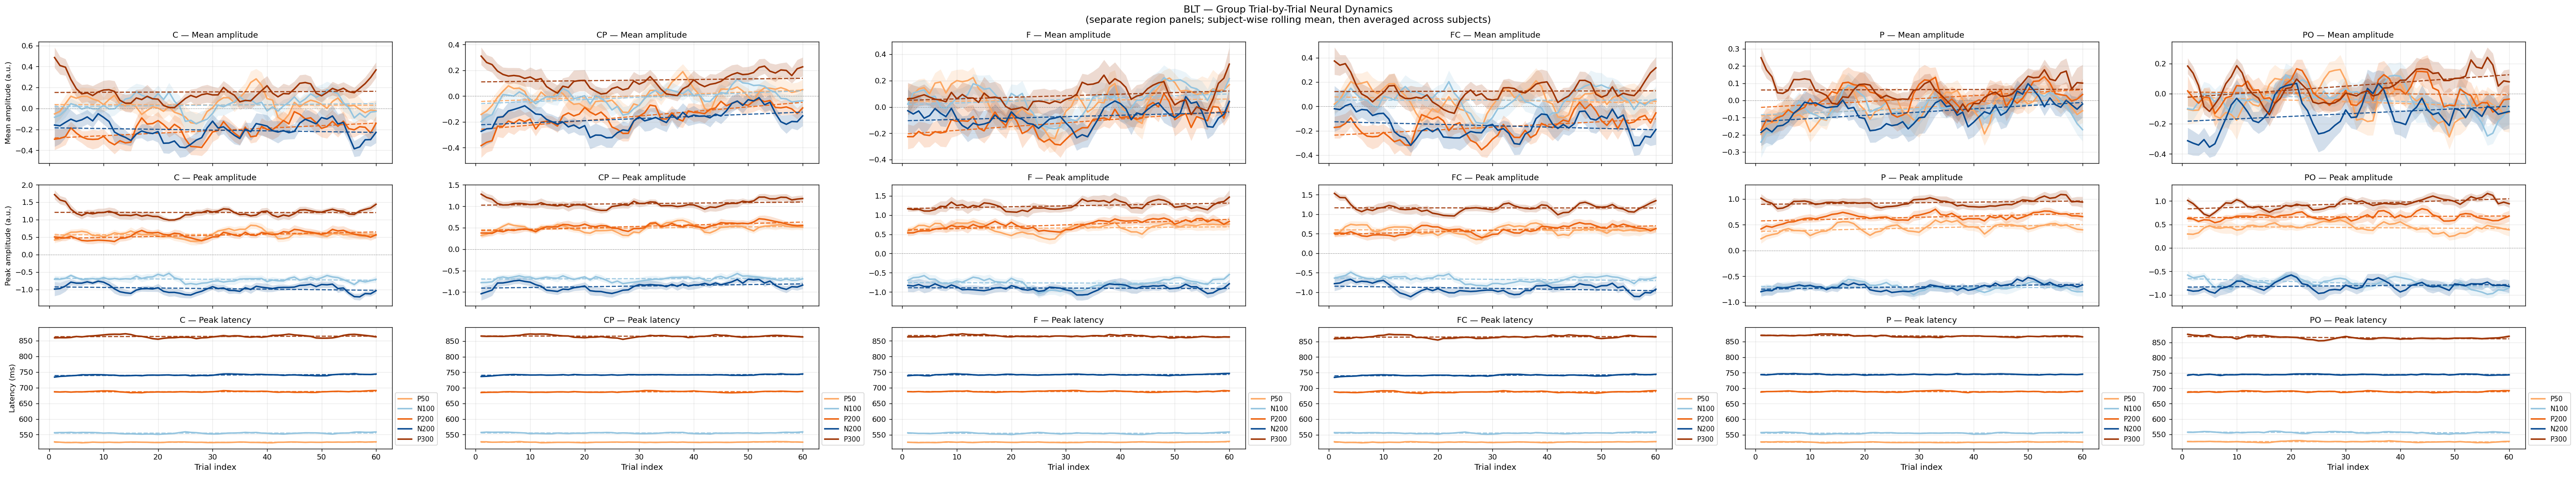

,region,component,metric_suffix,metric_title,mean_col,slope,intercept,rvalue,r2,pvalue,stderr,n
0,C,P50,mean_amp_roll_mean,Mean amplitude,P50_mean_amp_roll_mean,-0.000111,0.036762,-0.022519,0.000507,0.864396,0.000644,60
1,C,N100,mean_amp_roll_mean,Mean amplitude,N100_mean_amp_roll_mean,0.000483,0.016896,0.104349,0.010889,0.427517,0.000604,60
2,C,P200,mean_amp_roll_mean,Mean amplitude,P200_mean_amp_roll_mean,0.002402,-0.284327,0.514981,0.265205,0.000026,0.000525,60
3,C,N200,mean_amp_roll_mean,Mean amplitude,N200_mean_amp_roll_mean,-0.000736,-0.184705,-0.148907,0.022173,0.256161,0.000642,60
4,C,P300,mean_amp_roll_mean,Mean amplitude,P300_mean_amp_roll_mean,0.000182,0.152145,0.034301,0.001177,0.794722,0.000696,60
...,...,...,...,...,...,...,...,...,...,...,...,...
85,PO,P50,peak_lat_ms_roll_mean,Peak latency,P50_peak_lat_ms_roll_mean,-0.022844,526.411197,-0.250364,0.062682,0.053686,0.011599,60
86,PO,N100,peak_lat_ms_roll_mean,Peak latency,N100_peak_lat_ms_roll_mean,-0.042576,557.218601,-0.335244,0.112388,0.008834,0.015711,60
87,PO,P200,peak_lat_ms_roll_mean,Peak latency,P200_peak_lat_ms_roll_mean,-0.004524,689.152785,-0.043957,0.001932,0.738765,0.013502,60
88,PO,N200,peak_lat_ms_roll_mean,Peak latency,N200_peak_lat_ms_roll_mean,-0.000753,744.855737,-0.010053,0.000101,0.939231,0.009829,60


In [48]:
res_df = trial_dynamics.plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=True,
    b_fit_linear=True,
    b_plot_fit=True,
)
display(res_df)

res_df.to_csv(f"output/{CONDITION}_{ROI_NAME}_trial_dynamics_results.csv", index=False)

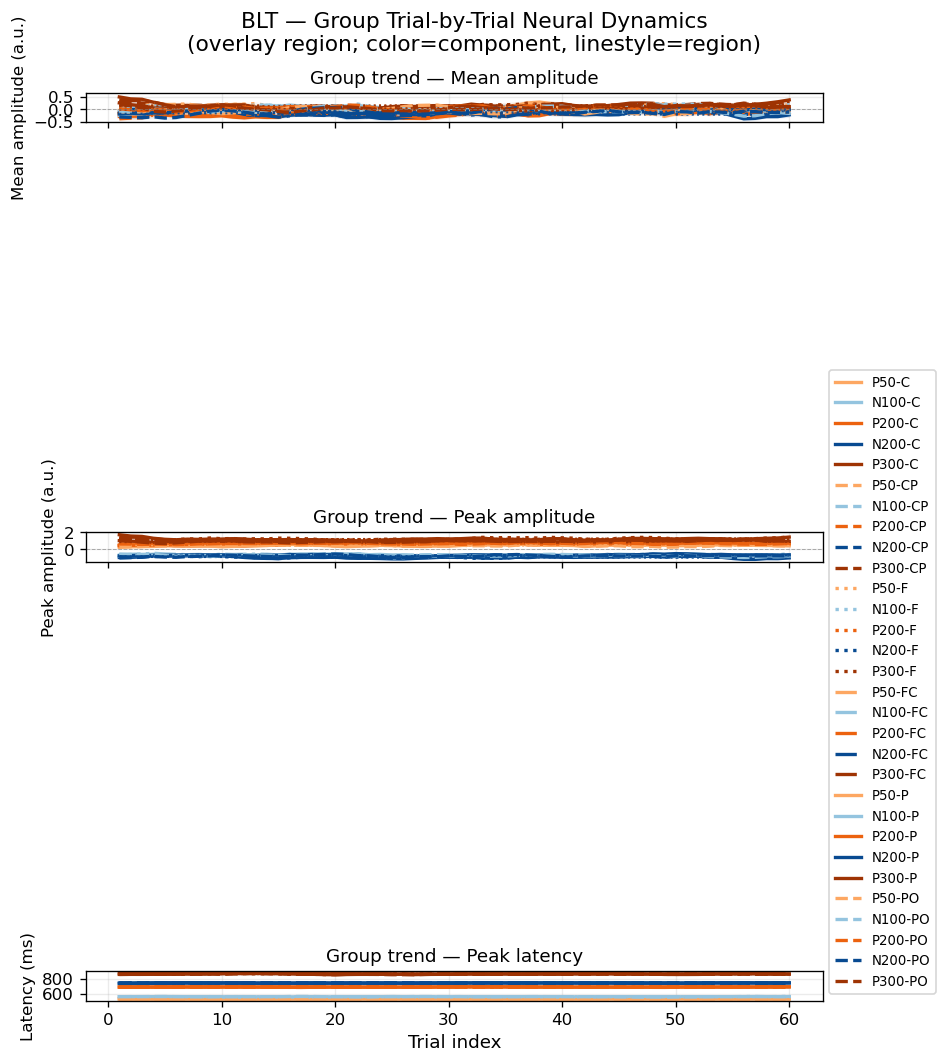

In [49]:
_ = trial_dynamics.plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=False,
    b_fit_linear=True,
    b_plot_fit=True,
)